### Create anndata object for Haber, 2017 LGR5+ stem cells

- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 19th August 2024
- **Last modified date:** 15th of November 2024

This notebook intends to create anndata object from Hber, 2017 Smart-seq2 dataset. In this notebook, we:
* Preprocess SRA metadata to identify which .sra files belong to the dataset of out interest (the SRA study from this study contains Smart-seq2 and 10X datasets). We extract the list of sra files that we need, to use for mapping.
* When the files are mapped, we create anndata object from them. We extract cell metadata (FACS information, cell type, donorID) we use AtlasFullLength_TPM countmatrix, which is publicly available, and merge this information to our raw anndata object.
* Perform basic quality check of the object.

### Import packages

In [104]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
from datetime import datetime
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
timestamp

'15112024_113549'

### Preprocessing SRA metadata

In [106]:
sra_study_metadata = pd.read_csv('raw_fastq_files/Haber_2017/GSE92332/SraRunTable.txt', sep=',')

+ Leave only healthy cells 

In [107]:
sra_study_metadata = sra_study_metadata[sra_study_metadata['treatment'].isnull()]

+ Leave only wild type donor

In [108]:
sra_study_metadata = sra_study_metadata[sra_study_metadata['source_name']== 'WT Mouse intestinal epithelial cells']

+ Leave only Smartseq data (Smart-seq2 entry has information about one cell only, when 10X contains many cells, therefore, 10X data is much larger and we can select Smart-seq2 by the number of bases in the sra entry)

In [109]:
sra_study_metadata = sra_study_metadata[sra_study_metadata['Bases']< 2000000000]

+ Select the list of sra objects that fit our requirements. This list we will use for datat download and mapping.

In [110]:
#sra_study_metadata['Run'].to_csv('raw_fastq_files/Haber_2017/run_column.txt', index=False, header=False)

### Create anndata object from remapped data

In [111]:
countmatrix = pd.read_csv('raw_data/Haber_2017/counts.txt', 
                          sep='\t', 
                          comment='#', 
                          skiprows=1)

In [112]:
countmatrix.columns = countmatrix.columns.str.split('/').str[-1].str.replace('_Aligned.sortedByCoord.out.bam', '')

In [113]:
countmatrix = countmatrix.set_index('Geneid')

In [114]:
countmatrix

,Chr,Start,End,Strand,Length,SRR5101952,SRR5101955,SRR5101956,SRR5101958,SRR5101960,...,SRR5103855,SRR5103856,SRR5103857,SRR5103858,SRR5103859,SRR5103860,SRR5103861,SRR5103862,SRR5103863,SRR5103864
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,29,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095475.2,JH584299.1;JH584299.1;JH584299.1,910289;911753;912797,910856;912343;913083,-;-;-,1446,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000094855.2,JH584299.1;JH584299.1;JH584299.1,921942;922694;924108,922228;923284;924675,+;+;+,1446,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000095019.2,JH584303.1,81607,82689,+,1083,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


+ Upload publicly available TPM matrix, because it contains cell metadata

In [115]:
AtlasFullLength_TPM = pd.read_csv('raw_fastq_files/Haber_2017/GSE92332/GSE92332_AtlasFullLength_TPM.txt', sep='\t', index_col=0)
AtlasFullLength_TPM = AtlasFullLength_TPM.T
AtlasFullLength_TPM.head()

,0610005C13Rik,0610007N19Rik,0610007P14Rik,0610008F07Rik,0610009B14Rik,0610009B22Rik,0610009D07Rik,0610009L18Rik,0610009O20Rik,0610010B08Rik,...,Zxda,Zxdb,Zxdc,Zyg11a,Zyg11b,Zyx,Zzef1,Zzz3,a,l7Rn6
S634_Lgr5GFP_M7_GFPLow_Enterocyte,103.90,21.93,150.61,8.6,0.0,59.52,33.52,0.0,1.08,0.64,...,0.00,1.67,1.04,0.0,3.82,11.72,55.49,0.00,0.0,5.99
S745_Lgr5GFP_M7_GFPLow_Stem,0.00,70.47,0.00,0.0,0.0,10.22,51.87,0.0,54.82,45.11,...,0.22,0.00,7.72,0.0,12.01,3.77,4.03,0.00,0.0,53.27
S856_Lgr5GFP_M7_GFPLow_Stem,8.99,20.84,0.00,0.0,0.0,76.65,219.94,0.0,57.28,7.79,...,0.00,0.00,0.00,0.0,0.26,0.00,14.46,0.56,0.0,57.09
S967_Lgr5GFP_M7_GFPLow_Goblet,0.00,67.15,212.32,0.0,0.0,64.97,45.24,0.0,135.89,0.00,...,0.00,0.00,0.00,0.0,5.01,0.00,33.99,0.00,0.0,37.72
S1078_Lgr5GFP_M7_GFPLow_Goblet,50.94,36.25,104.89,0.0,0.0,63.68,93.14,0.0,1.05,0.00,...,0.39,0.00,0.00,0.0,0.47,0.00,16.56,15.39,0.0,0.00


In [116]:
AtlasFullLength_TPM['barcode'] = AtlasFullLength_TPM.index.copy()

In [117]:
AtlasFullLength_TPM[['barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type']] = AtlasFullLength_TPM['barcode'].str.split('_', expand=True)

In [118]:
AtlasFullLength_TPM.head()

,0610005C13Rik,0610007N19Rik,0610007P14Rik,0610008F07Rik,0610009B14Rik,0610009B22Rik,0610009D07Rik,0610009L18Rik,0610009O20Rik,0610010B08Rik,...,Zyx,Zzef1,Zzz3,a,l7Rn6,barcode,Gene_marker,Donor_ID,GFP_intensity,Cell_Type
S634_Lgr5GFP_M7_GFPLow_Enterocyte,103.90,21.93,150.61,8.6,0.0,59.52,33.52,0.0,1.08,0.64,...,11.72,55.49,0.00,0.0,5.99,S634,Lgr5GFP,M7,GFPLow,Enterocyte
S745_Lgr5GFP_M7_GFPLow_Stem,0.00,70.47,0.00,0.0,0.0,10.22,51.87,0.0,54.82,45.11,...,3.77,4.03,0.00,0.0,53.27,S745,Lgr5GFP,M7,GFPLow,Stem
S856_Lgr5GFP_M7_GFPLow_Stem,8.99,20.84,0.00,0.0,0.0,76.65,219.94,0.0,57.28,7.79,...,0.00,14.46,0.56,0.0,57.09,S856,Lgr5GFP,M7,GFPLow,Stem
S967_Lgr5GFP_M7_GFPLow_Goblet,0.00,67.15,212.32,0.0,0.0,64.97,45.24,0.0,135.89,0.00,...,0.00,33.99,0.00,0.0,37.72,S967,Lgr5GFP,M7,GFPLow,Goblet
S1078_Lgr5GFP_M7_GFPLow_Goblet,50.94,36.25,104.89,0.0,0.0,63.68,93.14,0.0,1.05,0.00,...,0.00,16.56,15.39,0.0,0.00,S1078,Lgr5GFP,M7,GFPLow,Goblet


+ Lets create anndata object from this TPM normalized data as well

In [119]:
X = AtlasFullLength_TPM.iloc[:, 1:20108] 
var = pd.DataFrame(index=AtlasFullLength_TPM.columns[1:20108])
obs = AtlasFullLength_TPM.iloc[:, 20108:20114]

adataTPM = ad.AnnData(X=X.values, var=var, obs=obs)
adataTPM

AnnData object with n_obs × n_vars = 1522 × 20107
    obs: 'barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type'

In [120]:
project = 'gut'
species = 'mm'
atribute = 'Haber2017_SmartSeq2'
name = 'AM'
counts = 'TPM_normalized'

adataTPM.uns['processing_history'] = []
adataTPM.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'created anndata object from TPM normalized counts',}

adataTPM.write_h5ad(f"raw_data/Haber_2017/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

### Add metadata to our remapped countmatrix

* Currently, we are facing such problem: our metadata from TPM countmatrix has cell barcodes, our remapped metadata has SRA accession numbers (SRA...), the sra metadata that we processed on the start of our notebook has SRA accession number (SRA...) and SRA experiment (SRX...), and we found another csv table with SRA experiment (SRX...) and cell barcodes data. Now, the goal is to connect cell barcodes with SRA accession numbers, so we can merge metadata to our remapped metadata.

+ Upload table which has SRA experiment and cell barcodes data

In [121]:
dataframe = pd.read_csv('raw_data/Haber_2017/sample_database.csv')
dataframe = dataframe[dataframe['Title'].str.contains('Atlas WT single cell ')]
dataframe['barcode'] = dataframe['Title'].str.split('Atlas WT single cell ').str[1]
dataframe['barcode'] = 'S' + dataframe['barcode']

In [122]:
dataframe.rename(columns={'SRA Accession': 'SRA Experiment'}, inplace=True)

In [123]:
dataframe[0:5]

,Accession,Title,Sample Type,Taxonomy,Channels,Platform,Series,Supplementary Types,Supplementary Links,SRA Experiment,Contact,Release Date,barcode
391,GSM2426221,Atlas WT single cell 1,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418501,Adam Haber,"Nov 06, 2017",S1
392,GSM2426222,Atlas WT single cell 2,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418502,Adam Haber,"Nov 06, 2017",S2
393,GSM2426223,Atlas WT single cell 3,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418503,Adam Haber,"Nov 06, 2017",S3
394,GSM2426224,Atlas WT single cell 4,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418504,Adam Haber,"Nov 06, 2017",S4
395,GSM2426225,Atlas WT single cell 5,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418505,Adam Haber,"Nov 06, 2017",S5


+ Join the SRA accession number to the dataframe

In [124]:
dataframe = dataframe.merge(sra_study_metadata[['Experiment', 'Run']], left_on='SRA Experiment', right_on='Experiment', how='left')
dataframe = dataframe.drop(columns=['Experiment'])
dataframe.head()

,Accession,Title,Sample Type,Taxonomy,Channels,Platform,Series,Supplementary Types,Supplementary Links,SRA Experiment,Contact,Release Date,barcode,Run
0,GSM2426221,Atlas WT single cell 1,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418501,Adam Haber,"Nov 06, 2017",S1,SRR5102341
1,GSM2426222,Atlas WT single cell 2,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418502,Adam Haber,"Nov 06, 2017",S2,SRR5102342
2,GSM2426223,Atlas WT single cell 3,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418503,Adam Haber,"Nov 06, 2017",S3,SRR5102343
3,GSM2426224,Atlas WT single cell 4,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418504,Adam Haber,"Nov 06, 2017",S4,SRR5102344
4,GSM2426225,Atlas WT single cell 5,SRA,Mus musculus,1,GPL19057,GSE92332,SRA Run Selector,https://www.ncbi.nlm.nih.gov/Traces/study/?acc...,SRX2418505,Adam Haber,"Nov 06, 2017",S5,SRR5102345


In [125]:
dataframe.rename(columns={'Run': 'SRA Accession'}, inplace=True)

+ Add SRA Accession to metadata 

In [126]:
sra_accession_df = dataframe[['barcode', 'SRA Accession']]
adataTPM.obs = adataTPM.obs.merge(sra_accession_df, left_on='barcode', right_on='barcode', how='left')

In [127]:
adataTPM.obs

,barcode,Gene_marker,Donor_ID,GFP_intensity,Cell_Type,SRA Accession
0,S634,Lgr5GFP,M7,GFPLow,Enterocyte,SRR5102975
1,S745,Lgr5GFP,M7,GFPLow,Stem,SRR5103086
2,S856,Lgr5GFP,M7,GFPLow,Stem,SRR5103197
3,S967,Lgr5GFP,M7,GFPLow,Goblet,SRR5103308
4,S1078,Lgr5GFP,M7,GFPLow,Goblet,SRR5103419
...,...,...,...,...,...,...
1517,S575,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,SRR5102916
1518,S576,WT,M3,GFP-.CD24-.EpCAM+,Tuft-1,SRR5102917
1519,S578,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,SRR5102919
1520,S579,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,SRR5102920


+ Merge metadata to countmatrix

In [128]:
countmatrix = countmatrix.T
countmatrix = countmatrix.iloc[5:]
countmatrix.head(10)

Geneid,ENSMUSG00000102693.2,ENSMUSG00000064842.3,ENSMUSG00000051951.6,ENSMUSG00000102851.2,ENSMUSG00000103377.2,ENSMUSG00000104017.2,ENSMUSG00000103025.2,ENSMUSG00000089699.3,ENSMUSG00000103201.2,ENSMUSG00000103147.2,...,ENSMUSG00000094172.2,ENSMUSG00000094887.2,ENSMUSG00000091585.3,ENSMUSG00000095763.2,ENSMUSG00000095523.2,ENSMUSG00000095475.2,ENSMUSG00000094855.2,ENSMUSG00000095019.2,ENSMUSG00000144201.1,ENSMUSG00000095041.8
SRR5101952,0,0,29,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,37
SRR5101955,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
SRR5101956,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
SRR5101958,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
SRR5101960,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,59
SRR5101965,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,57
SRR5101968,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20
SRR5101970,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,50
SRR5101973,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,222
SRR5101979,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,61


In [129]:
countmatrix.shape

(1604, 78298)

In [130]:
adataTPM.shape

(1522, 20107)

In [131]:
countmatrix_rows = set(countmatrix.index)
sra_accessions = set(adataTPM.obs['SRA Accession'])
missing_in_countmatrix_rows = sra_accessions - countmatrix_rows
len(missing_in_countmatrix_rows)

9

In [132]:
countmatrix['SRA Accession'] = countmatrix.index
merged_df = pd.merge(adataTPM.obs, countmatrix, left_on='SRA Accession', right_on='SRA Accession', how='inner')
merged_df.set_index('SRA Accession', inplace=True)

In [133]:
merged_df

,barcode,Gene_marker,Donor_ID,GFP_intensity,Cell_Type,ENSMUSG00000102693.2,ENSMUSG00000064842.3,ENSMUSG00000051951.6,ENSMUSG00000102851.2,ENSMUSG00000103377.2,...,ENSMUSG00000094172.2,ENSMUSG00000094887.2,ENSMUSG00000091585.3,ENSMUSG00000095763.2,ENSMUSG00000095523.2,ENSMUSG00000095475.2,ENSMUSG00000094855.2,ENSMUSG00000095019.2,ENSMUSG00000144201.1,ENSMUSG00000095041.8
SRA Accession,,,,,,,,,,,,,,,,,,,,,
SRR5102975,S634,Lgr5GFP,M7,GFPLow,Enterocyte,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,631
SRR5103086,S745,Lgr5GFP,M7,GFPLow,Stem,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,583
SRR5103197,S856,Lgr5GFP,M7,GFPLow,Stem,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,274
SRR5103308,S967,Lgr5GFP,M7,GFPLow,Goblet,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,38
SRR5103530,S1189,Lgr5GFP,M7,GFPLow,TA,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR5102916,S575,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,113
SRR5102917,S576,WT,M3,GFP-.CD24-.EpCAM+,Tuft-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,430
SRR5102919,S578,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,38


+ Finally, we create anndata object

In [134]:
obs = merged_df.iloc[:, :5]
X = merged_df.iloc[:, 5:]
var = pd.DataFrame(index=X.columns)
adata_raw = ad.AnnData(X=X.values, obs=obs, var=var)

In [135]:
adata_raw.obs

,barcode,Gene_marker,Donor_ID,GFP_intensity,Cell_Type
SRA Accession,,,,,
SRR5102975,S634,Lgr5GFP,M7,GFPLow,Enterocyte
SRR5103086,S745,Lgr5GFP,M7,GFPLow,Stem
SRR5103197,S856,Lgr5GFP,M7,GFPLow,Stem
SRR5103308,S967,Lgr5GFP,M7,GFPLow,Goblet
SRR5103530,S1189,Lgr5GFP,M7,GFPLow,TA
...,...,...,...,...,...
SRR5102916,S575,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2
SRR5102917,S576,WT,M3,GFP-.CD24-.EpCAM+,Tuft-1
SRR5102919,S578,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2


In [136]:
adata_raw.obs['Cell_Type'] = adata_raw.obs['Cell_Type'].astype('str')
adata_raw.obs['Gene_marker'] = adata_raw.obs['Gene_marker'].astype('str')
adata_raw.obs['GFP_intensity'] = adata_raw.obs['GFP_intensity'].astype('str')
adata_raw.obs['cell_type_extended'] = adata_raw.obs['Cell_Type'] + '_' + adata_raw.obs['Gene_marker'] + '_' + adata_raw.obs['GFP_intensity']

In [137]:
adata_raw.obs['cell_type_extended'].value_counts()

cell_type_extended
Stem_Lgr5GFP_GFPHigh                                     367
Stem_WT_GFP-.CD24-.EpCAM+                                145
TA_Lgr5GFP_GFPLow                                         84
Enterocyte_WT_GFP-.CD24-.EpCAM+                           72
TA_WT_GFP-.CD24-.EpCAM+                                   70
Stem_Lgr5GFP_GFPLow                                       68
Enterocyte_Lgr5GFP_GFP-.CD24-.EpCAM+                      56
Enterocyte-Progenitor-Early_Lgr5GFP_GFPLow                55
Stem_Lgr5GFP_GFP-.CD24-.EpCAM+                            54
Goblet_WT_GFP-.CD24-.EpCAM+                               41
Paneth_Lgr5GFP_GFP-.CD24+.cKit+                           41
Goblet_Lgr5GFP_GFPLow                                     38
Enterocyte-Progenitor-Early_WT_GFP-.CD24-.EpCAM+          37
Enterocyte-Progenitor-Late_WT_GFP-.CD24-.EpCAM+           34
Tuft-1_Lgr5GFP_GFP-.CD24+                                 30
Goblet_Lgr5GFP_GFP-.CD24-.EpCAM+                          29
Enter

In [138]:
adata_raw.obs['Cell_Type']= adata_raw.obs['Cell_Type'].astype('category')
adata_raw.obs['Cell_Type'] = adata_raw.obs['Cell_Type'].cat.add_categories(['LGR5+ stem cell', 'LGR5- stem cell', 'LGR5- CD24- EpCAM+ stem cell'])
adata_raw.obs.loc[(adata_raw.obs['cell_type_extended'] == 'Stem_Lgr5GFP_GFPHigh'), 'Cell_Type'] = 'LGR5+ stem cell'
adata_raw.obs.loc[(adata_raw.obs['cell_type_extended'] == 'Stem_Lgr5GFP_GFPLow'), 'Cell_Type'] = 'LGR5- stem cell'
adata_raw.obs.loc[(adata_raw.obs['cell_type_extended'] == 'Stem_Lgr5GFP_GFP-.CD24-.EpCAM+'), 'Cell_Type'] = 'LGR5- CD24- EpCAM+ stem cell'

In [139]:
adata_raw.obs['Cell_Type'].value_counts()

Cell_Type
LGR5+ stem cell                 367
TA                              198
Enterocyte                      155
Stem                            145
Goblet                          121
Enterocyte-Progenitor-Early     114
Paneth                           77
Enterocyte-Progenitor-Late       70
LGR5- stem cell                  68
LGR5- CD24- EpCAM+ stem cell     54
Tuft-1                           50
Tuft-2                           49
Endocrine                        42
Tuft                              3
Name: count, dtype: int64

+ Add gene names

In [140]:
adata_raw.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095475.2
ENSMUSG00000094855.2
ENSMUSG00000095019.2
ENSMUSG00000144201.1


In [141]:
annot = sc.queries.biomart_annotations(
    "mmusculus",
    ["ensembl_gene_id", "start_position", "end_position", "chromosome_name", "external_gene_name",],
).set_index("ensembl_gene_id")

In [142]:
annot

,start_position,end_position,chromosome_name,external_gene_name
ensembl_gene_id,,,,
ENSMUSG00000064336,1,68,MT,mt-Tf
ENSMUSG00000064337,70,1024,MT,mt-Rnr1
ENSMUSG00000064338,1025,1093,MT,mt-Tv
ENSMUSG00000064339,1094,2675,MT,mt-Rnr2
ENSMUSG00000064340,2676,2750,MT,mt-Tl1
...,...,...,...,...
ENSMUSG00000087203,117606375,117942663,2,Gm13986
ENSMUSG00000085319,18032325,18045049,2,Gm13330
ENSMUSG00000086652,129000586,129026041,2,Gm14029


In [143]:
adata_raw.var['ensemble_gene_id_version'] = adata_raw.var.index.copy()

In [144]:
adata_raw.var['ensemble_gene_id'] = adata_raw.var['ensemble_gene_id_version'].str.split('.').str[0]

In [145]:
adata_raw.var.index = adata_raw.var['ensemble_gene_id']

In [146]:
adata_raw.var = adata_raw.var.merge(annot, left_index=True, right_index=True, how='left')

In [147]:
adata_raw.var

,ensemble_gene_id_version,ensemble_gene_id,start_position,end_position,chromosome_name,external_gene_name
ensemble_gene_id,,,,,,
ENSMUSG00000102693,ENSMUSG00000102693.2,ENSMUSG00000102693,3143476,3144545,1,4933401J01Rik
ENSMUSG00000064842,ENSMUSG00000064842.3,ENSMUSG00000064842,3172239,3172348,1,Gm26206
ENSMUSG00000051951,ENSMUSG00000051951.6,ENSMUSG00000051951,3276124,3741721,1,Xkr4
ENSMUSG00000102851,ENSMUSG00000102851.2,ENSMUSG00000102851,3322980,3323459,1,Gm18956
ENSMUSG00000103377,ENSMUSG00000103377.2,ENSMUSG00000103377,3435954,3438772,1,Gm37180
...,...,...,...,...,...,...
ENSMUSG00000095475,ENSMUSG00000095475.2,ENSMUSG00000095475,910289,913083,JH584299.1,NaN
ENSMUSG00000094855,ENSMUSG00000094855.2,ENSMUSG00000094855,921942,924675,JH584299.1,NaN
ENSMUSG00000095019,ENSMUSG00000095019.2,ENSMUSG00000095019,81607,82689,JH584303.1,NaN


In [148]:
adata_raw.obs

,barcode,Gene_marker,Donor_ID,GFP_intensity,Cell_Type,cell_type_extended
SRA Accession,,,,,,
SRR5102975,S634,Lgr5GFP,M7,GFPLow,Enterocyte,Enterocyte_Lgr5GFP_GFPLow
SRR5103086,S745,Lgr5GFP,M7,GFPLow,LGR5- stem cell,Stem_Lgr5GFP_GFPLow
SRR5103197,S856,Lgr5GFP,M7,GFPLow,LGR5- stem cell,Stem_Lgr5GFP_GFPLow
SRR5103308,S967,Lgr5GFP,M7,GFPLow,Goblet,Goblet_Lgr5GFP_GFPLow
SRR5103530,S1189,Lgr5GFP,M7,GFPLow,TA,TA_Lgr5GFP_GFPLow
...,...,...,...,...,...,...
SRR5102916,S575,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,Tuft-2_WT_GFP-.CD24-.EpCAM+
SRR5102917,S576,WT,M3,GFP-.CD24-.EpCAM+,Tuft-1,Tuft-1_WT_GFP-.CD24-.EpCAM+
SRR5102919,S578,WT,M3,GFP-.CD24-.EpCAM+,Tuft-2,Tuft-2_WT_GFP-.CD24-.EpCAM+


In [149]:
project = 'gut'
species = 'mm'
atribute = 'Haber2017_SmartSeq2'
name = 'AM'
counts = 'raw'

adata_raw.uns['processing_history'] = []
adata_raw.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'created raw anndata object',}

adata_raw.var = adata_raw.var.astype(str)
adata_raw.var.index = adata_raw.var.index.astype(str)
adata_raw.obs = adata_raw.obs.astype(str)
adata_raw.obs.index = adata_raw.obs.index.astype(str)
adata_raw.X = adata_raw.X.astype(float)

adata_raw.write_h5ad(f"raw_data/Haber_2017/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

+ Quality check

In [150]:
sc.pp.filter_genes(adata_raw, min_counts = 1, inplace = True)
sc.pp.filter_genes(adata_raw, min_cells = 3, inplace = True)

sc.pp.filter_cells(adata_raw, min_genes = 50, inplace = True)
sc.pp.filter_cells(adata_raw, min_counts = 3, inplace = True)
adata_raw

AnnData object with n_obs × n_vars = 1513 × 51241
    obs: 'barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type', 'cell_type_extended', 'n_genes', 'n_counts'
    var: 'ensemble_gene_id_version', 'ensemble_gene_id', 'start_position', 'end_position', 'chromosome_name', 'external_gene_name', 'n_counts', 'n_cells'
    uns: 'processing_history'

+ Check mitochondrial and ribosomal percentage

In [151]:
adata_raw.var.index = adata_raw.var['external_gene_name'].copy()

In [152]:
adata_raw.var['mt'] = adata_raw.var_names.str.startswith('mt-') 
adata_raw.var['ribo'] = adata_raw.var_names.str.startswith(("Rps","Rpl"))

In [153]:
sc.pp.calculate_qc_metrics(adata_raw, qc_vars = ['mt','ribo'], percent_top = None, log1p = False, inplace = True)

+ Visualize quality metrics

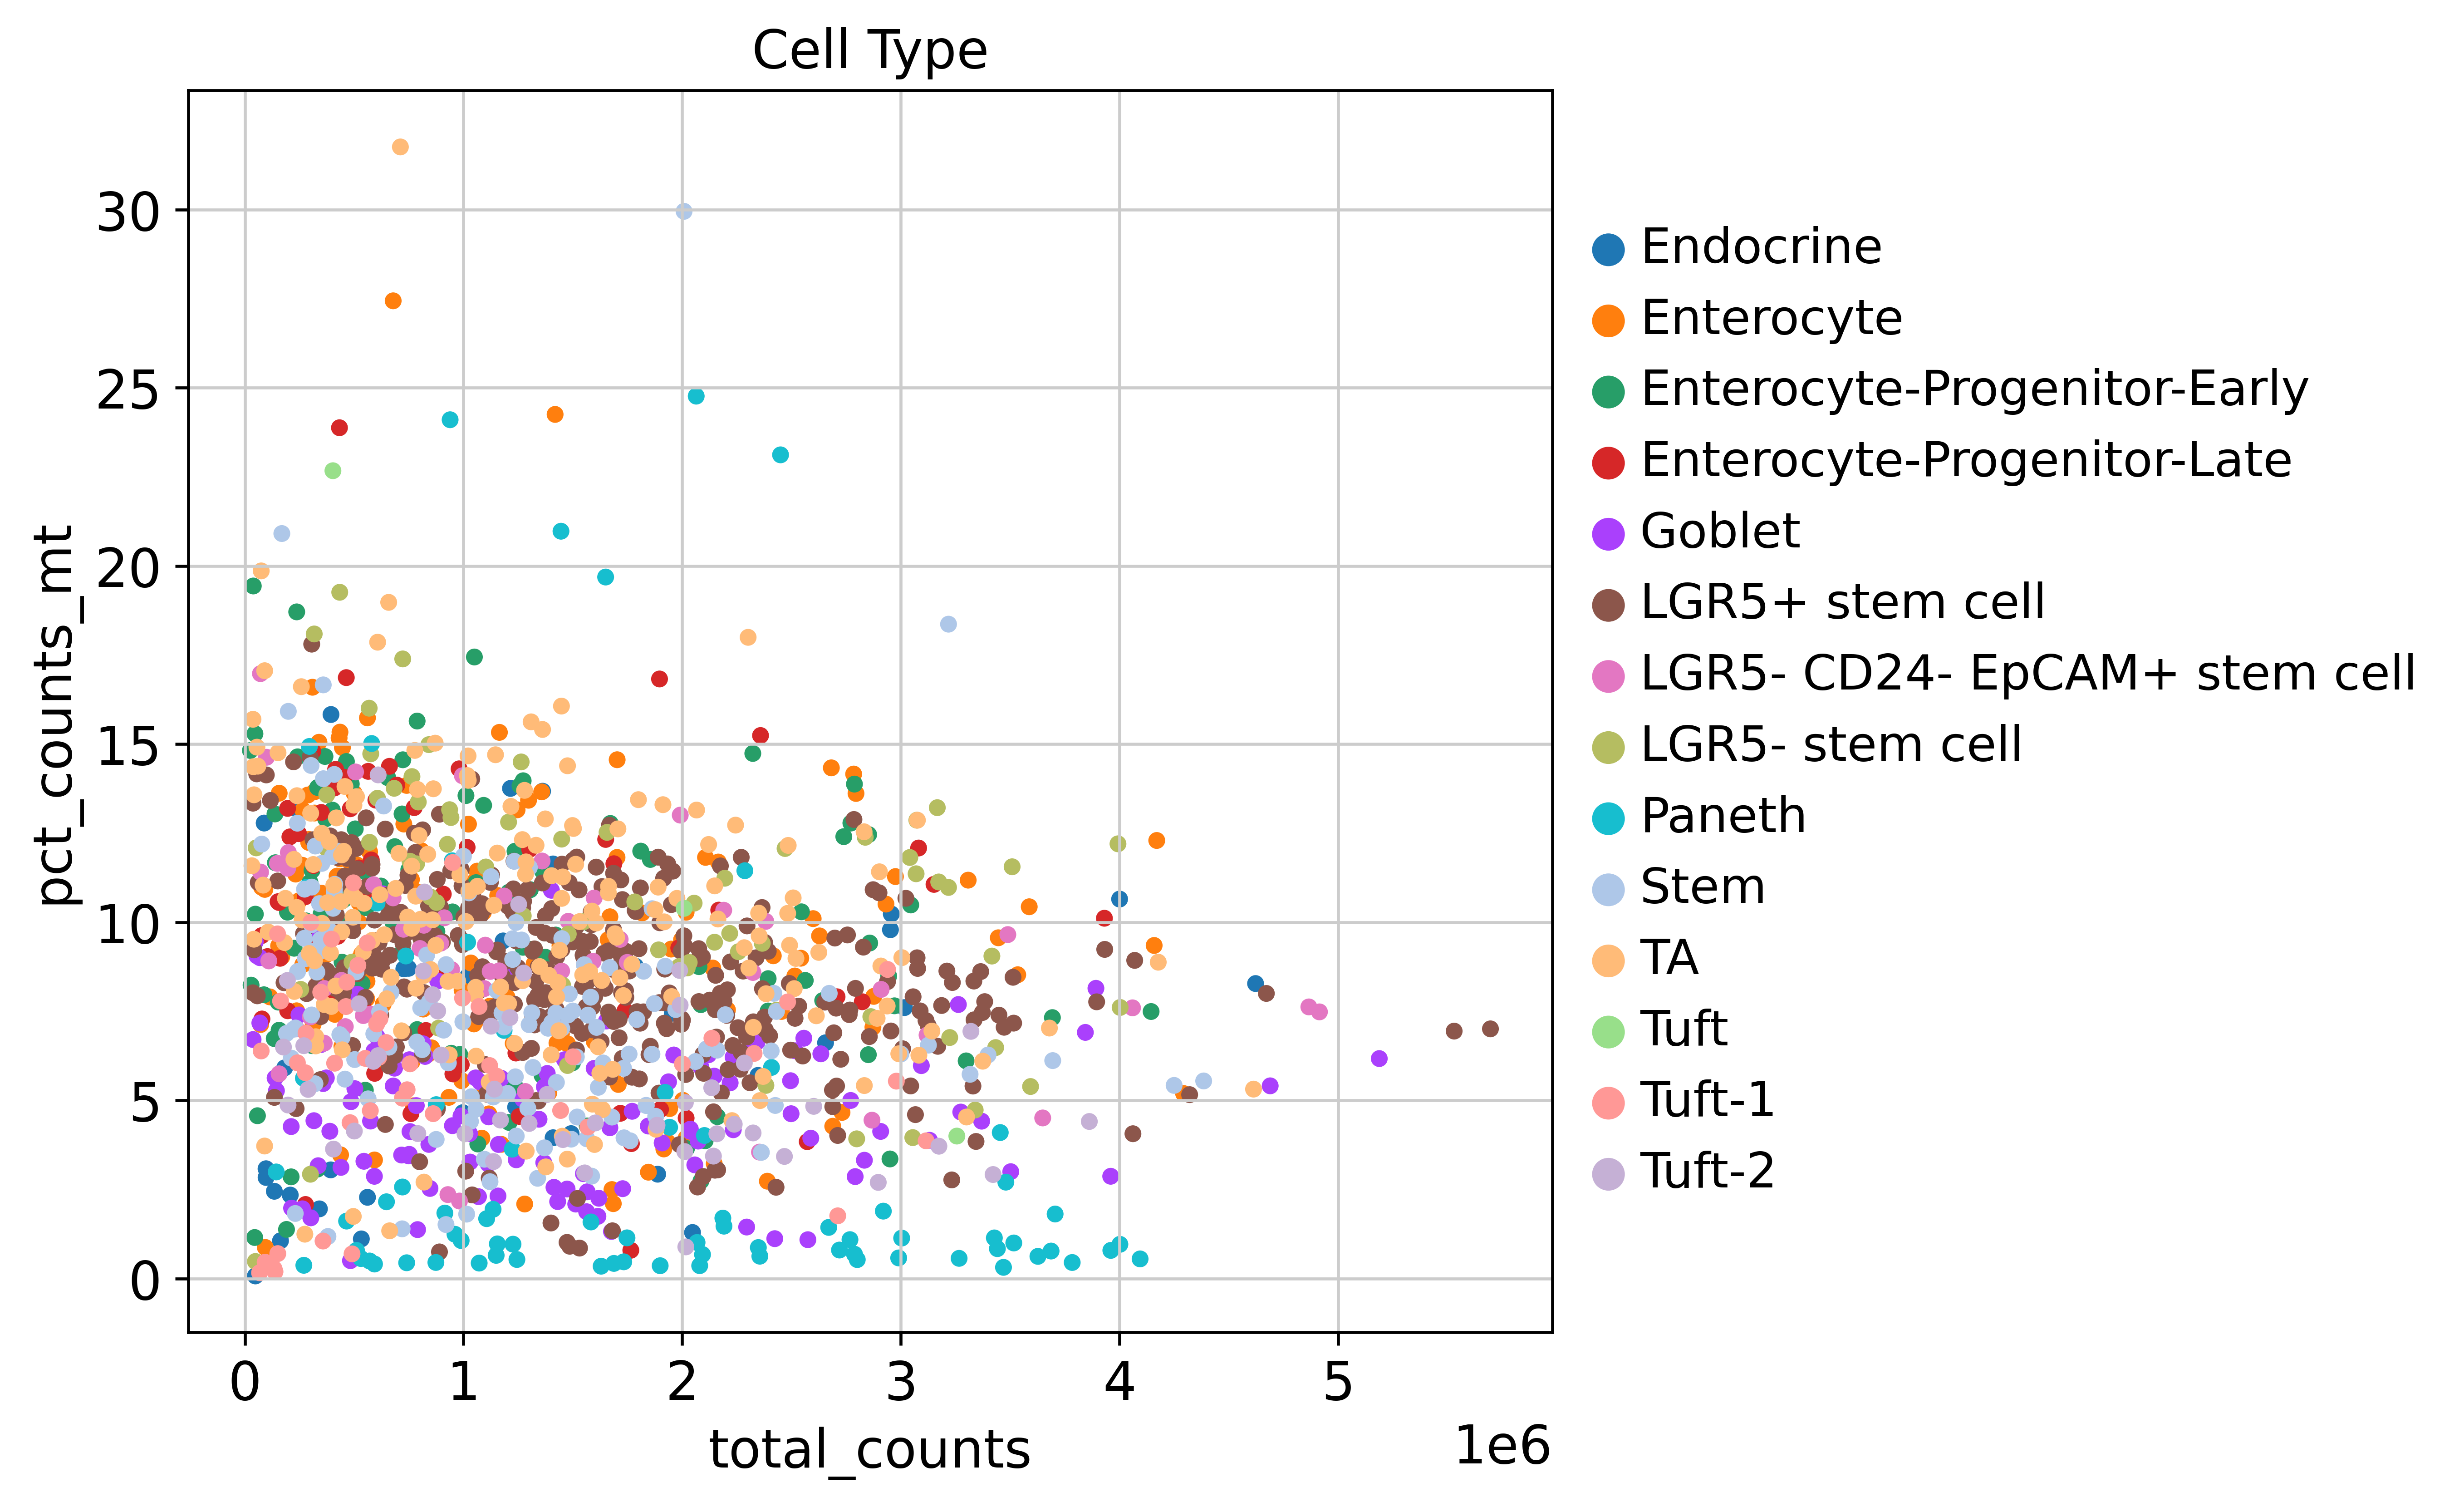

In [154]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_raw, x = 'total_counts', y = 'pct_counts_mt', color = "Cell_Type")

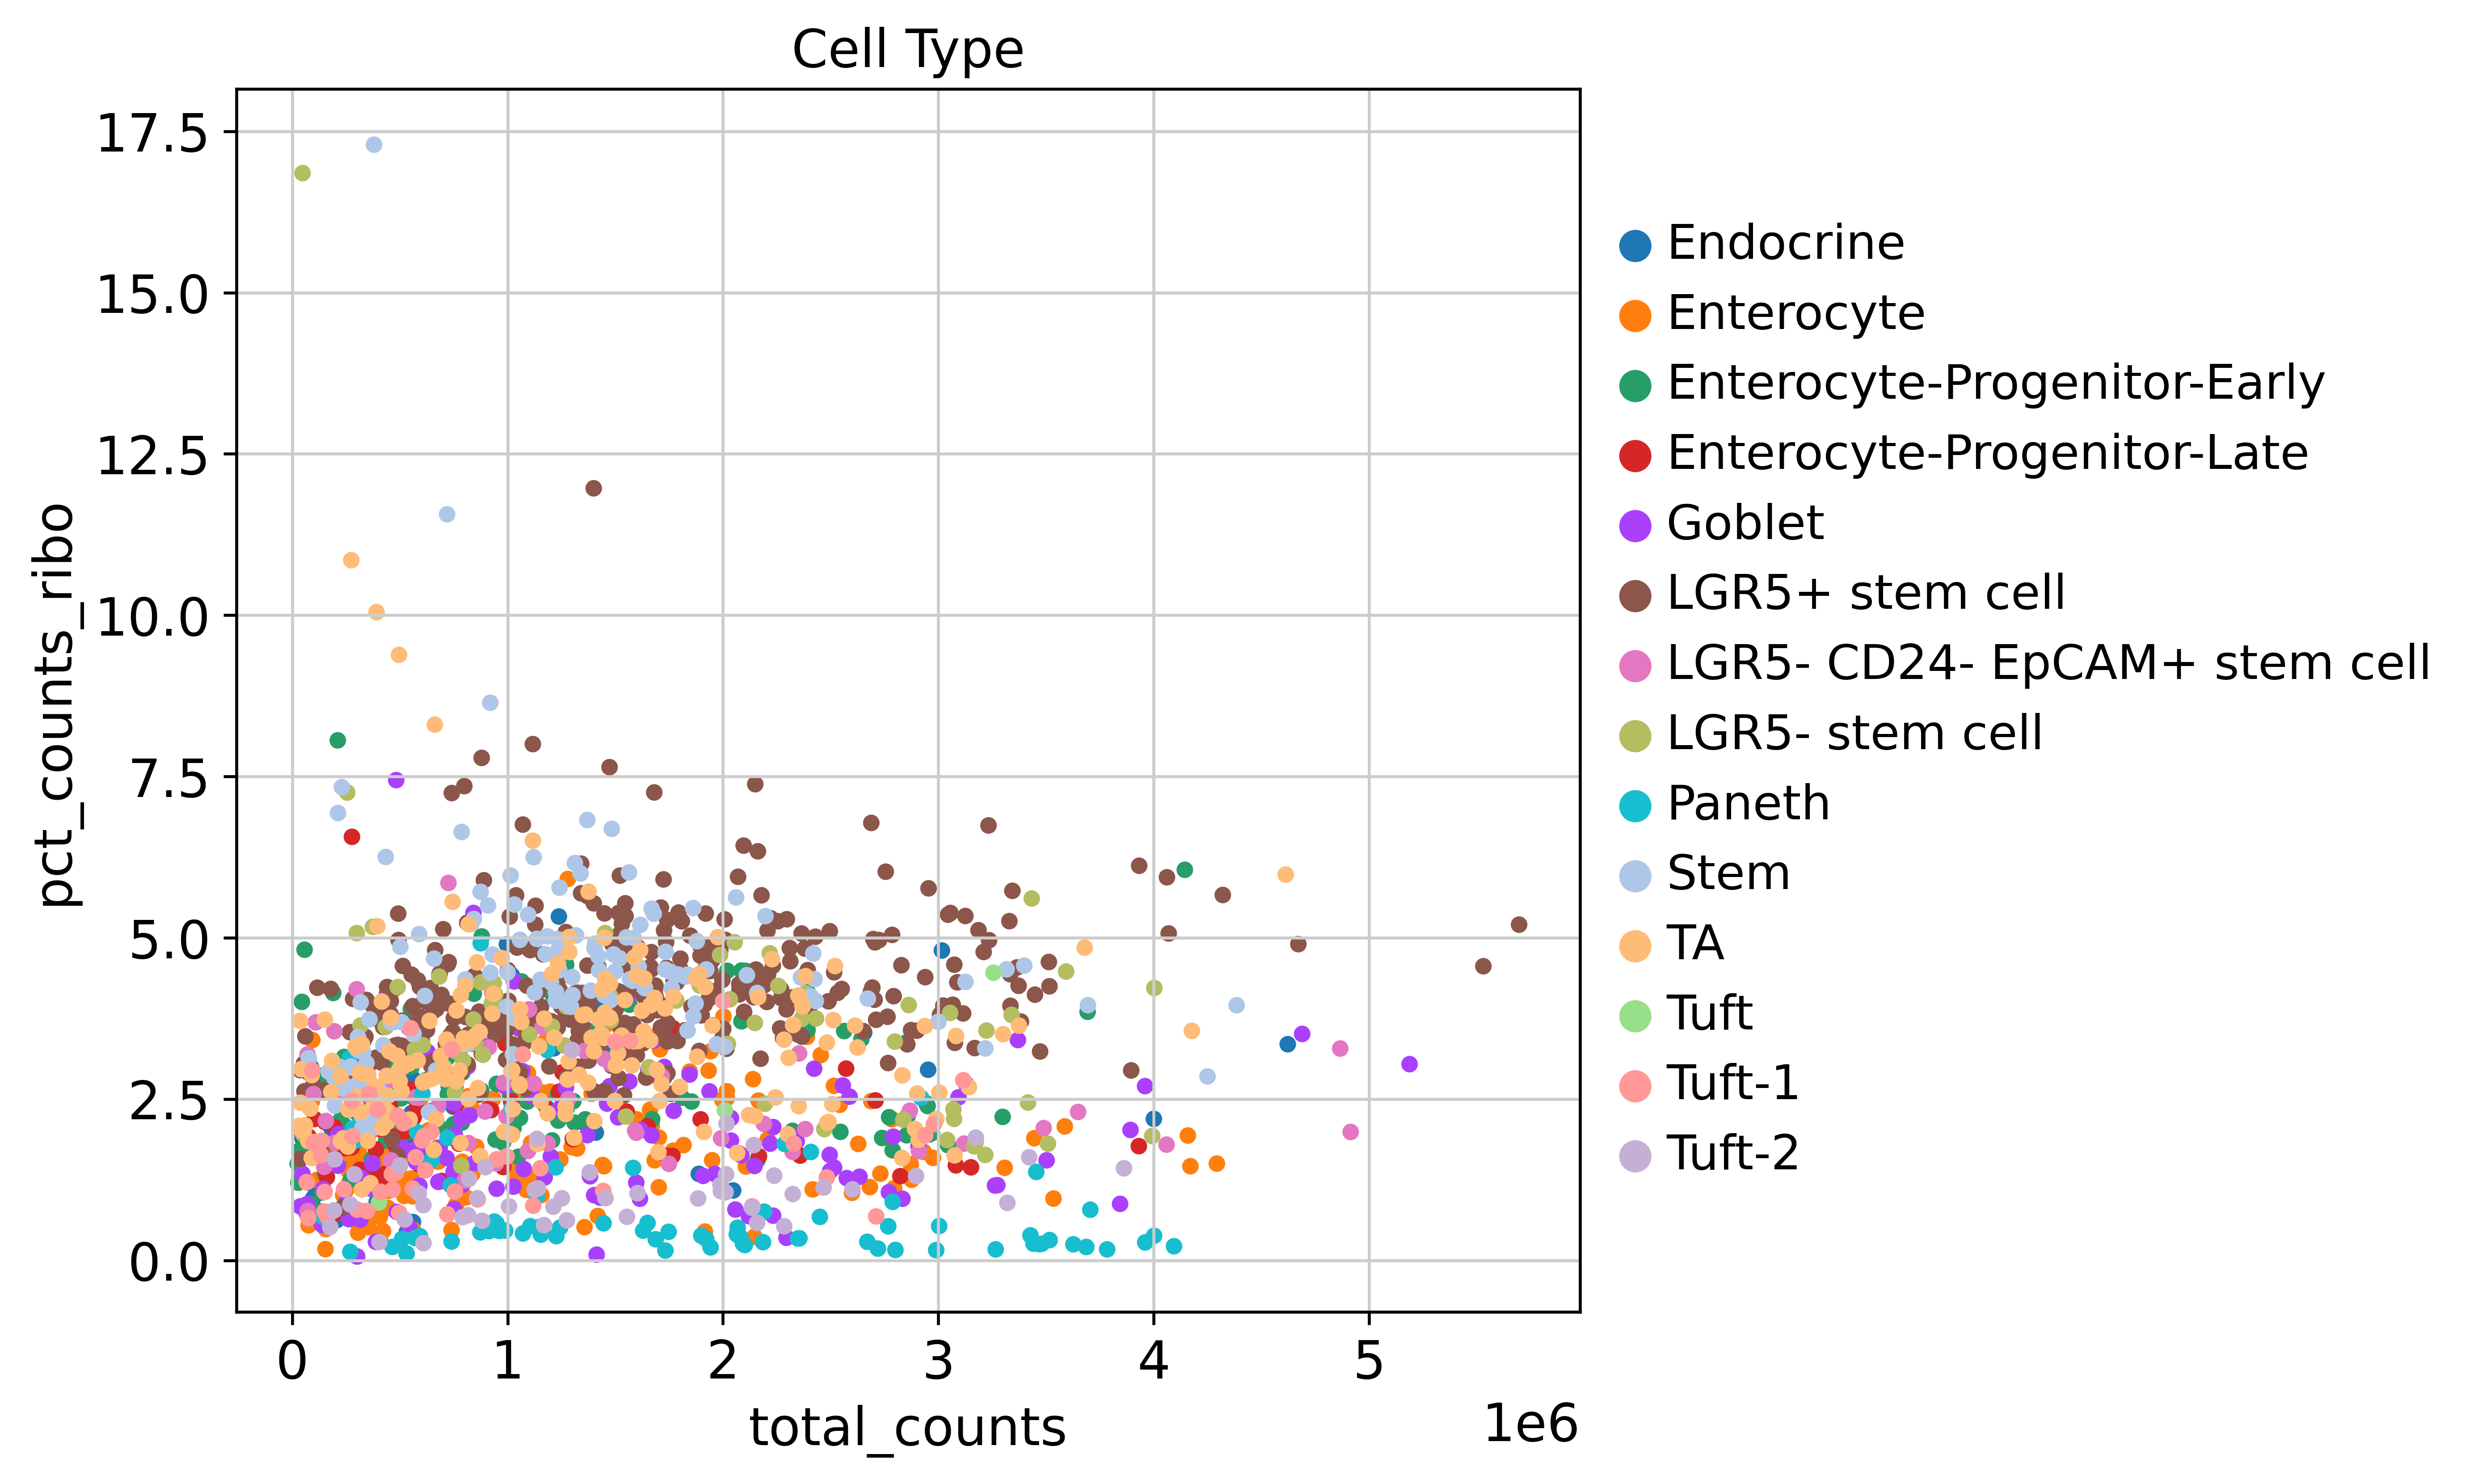

In [155]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_raw, x = 'total_counts', y = 'pct_counts_ribo', color = "Cell_Type")

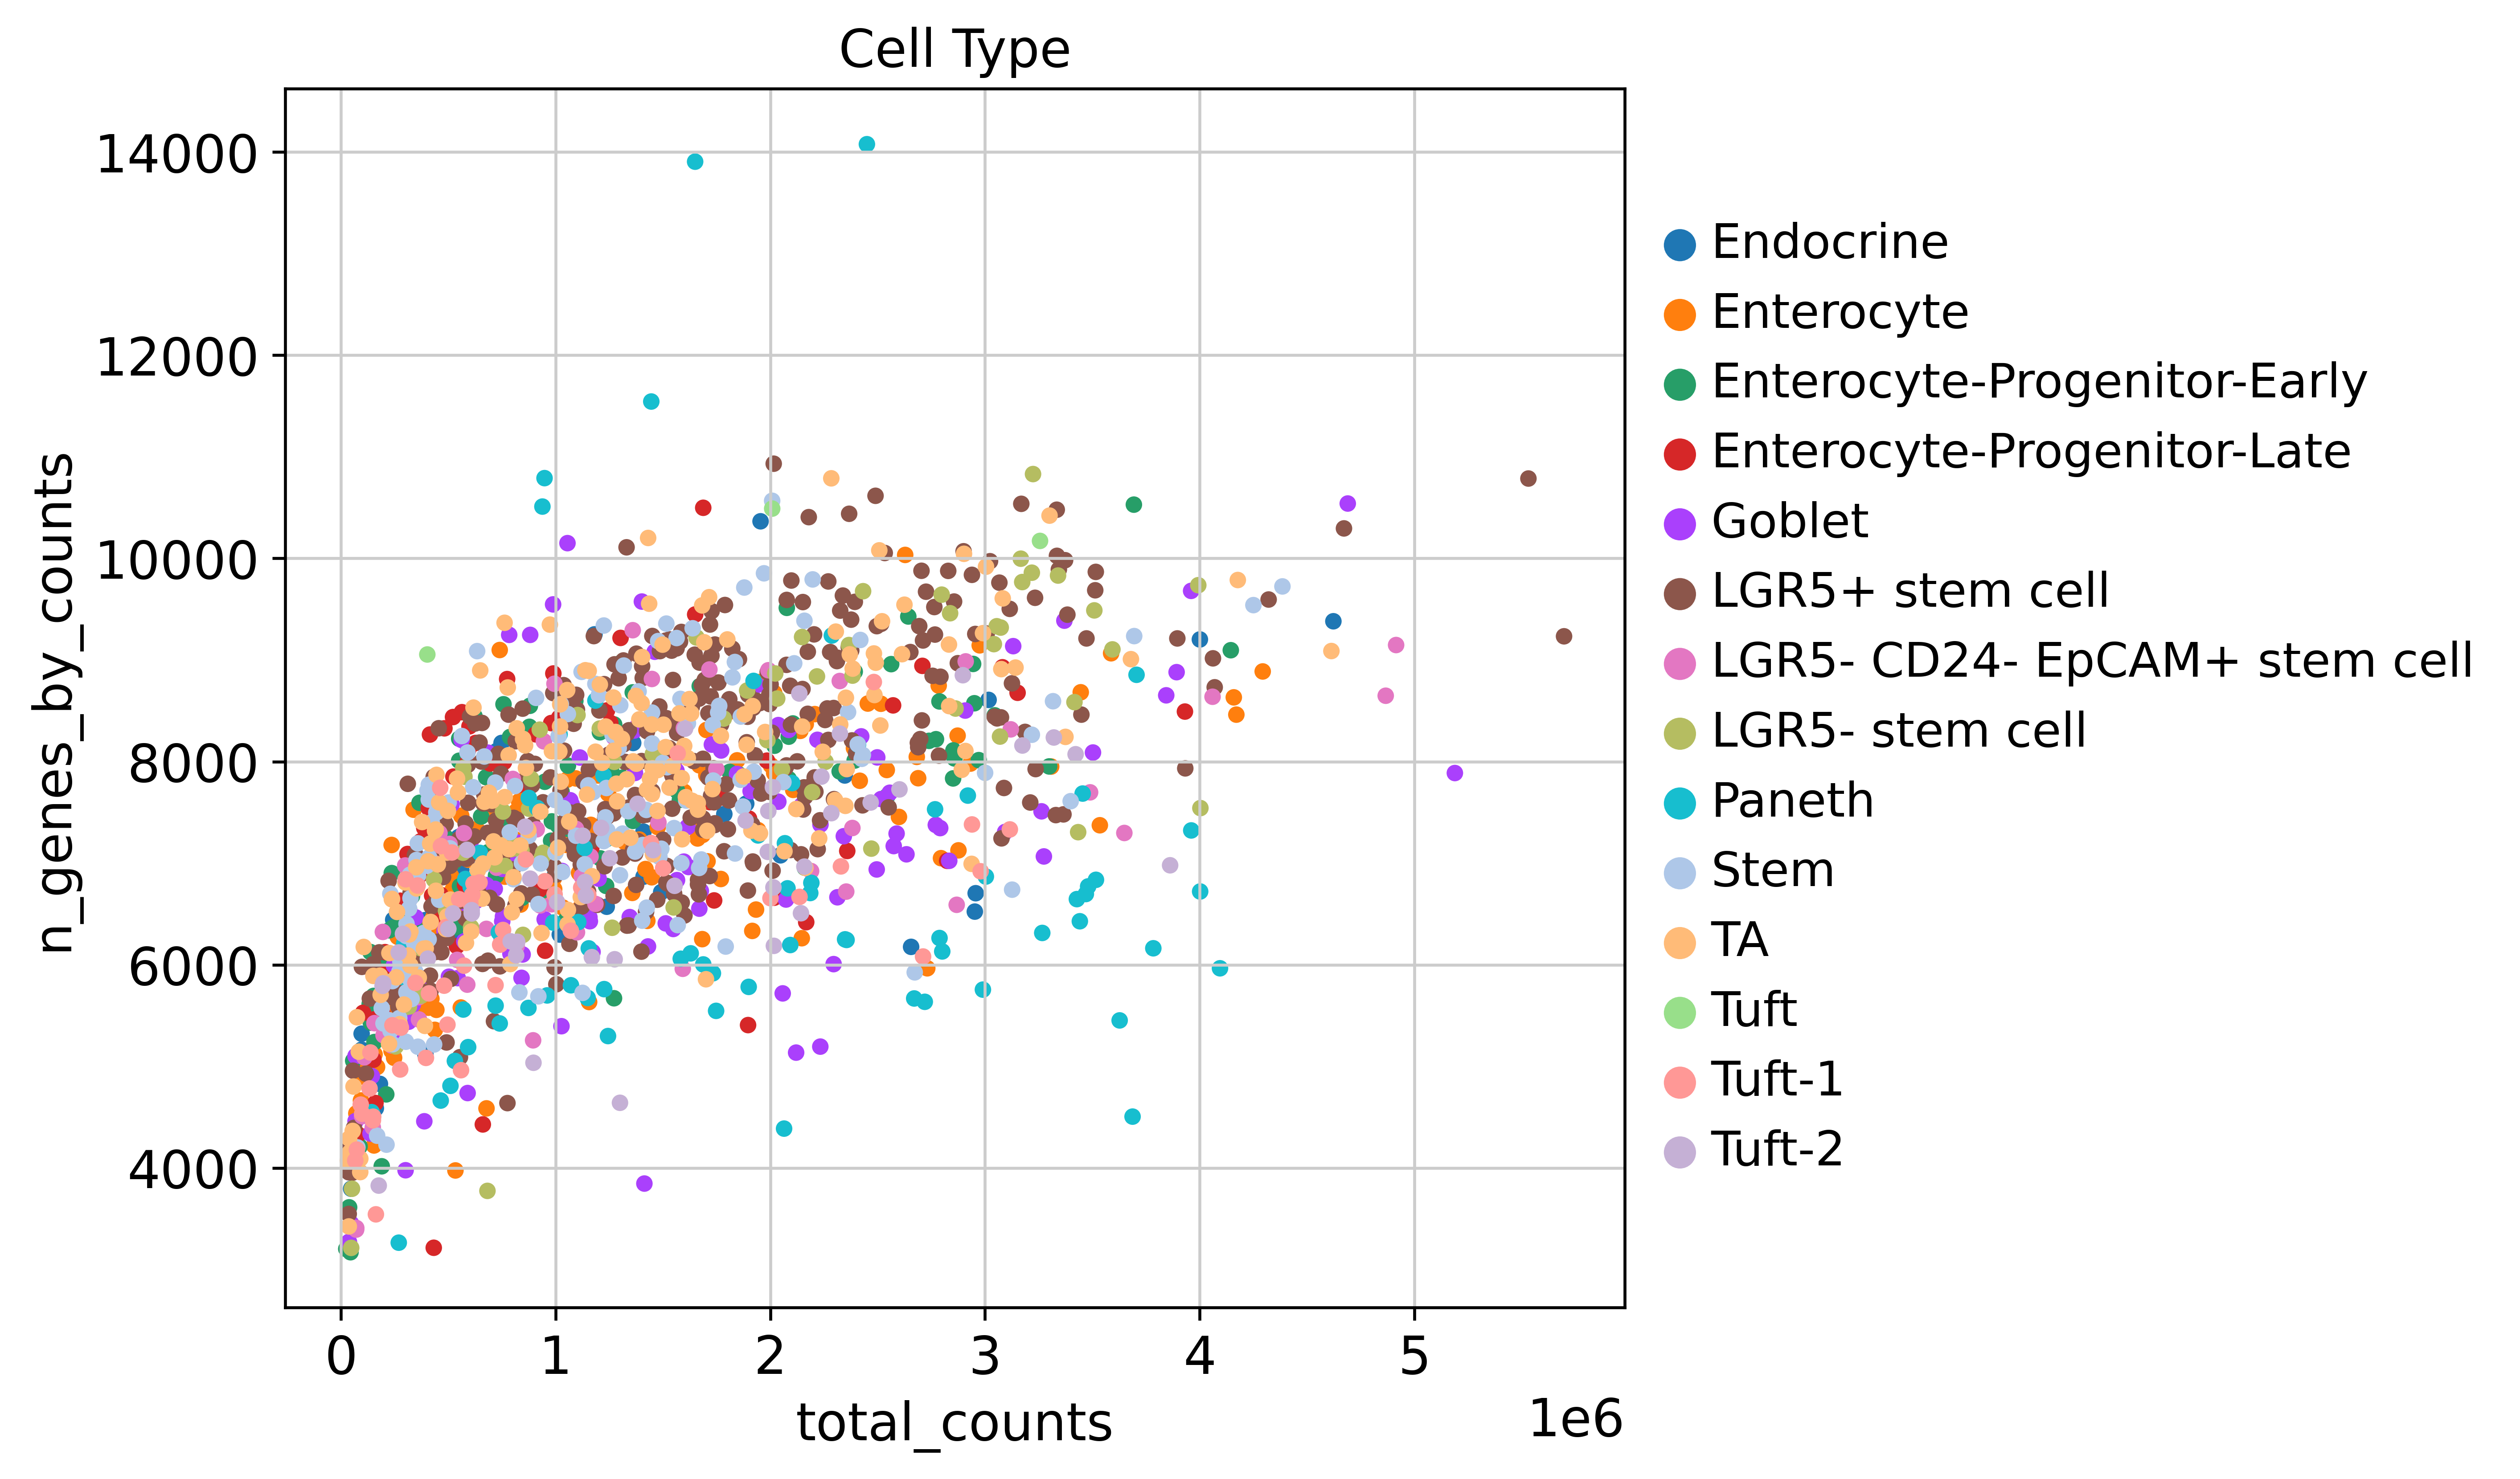

In [156]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_raw, x = 'total_counts', y = 'n_genes_by_counts', color = "Cell_Type")

In [157]:
adata_filtered = adata_raw[adata_raw.obs['n_genes_by_counts'] > 100]
adata_filtered = adata_filtered[adata_filtered.obs['n_genes_by_counts'] < 10000]

adata_filtered = adata_filtered[adata_filtered.obs['total_counts'] > 100]
adata_filtered = adata_filtered[adata_filtered.obs['total_counts'] < 4000000]

adata_filtered = adata_filtered[adata_filtered.obs['pct_counts_mt'] < 20]
adata_filtered = adata_filtered[adata_filtered.obs['pct_counts_ribo'] < 20]

In [158]:
adata_filtered

View of AnnData object with n_obs × n_vars = 1453 × 51241
    obs: 'barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type', 'cell_type_extended', 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'ensemble_gene_id_version', 'ensemble_gene_id', 'start_position', 'end_position', 'chromosome_name', 'external_gene_name', 'n_counts', 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'processing_history', 'Cell_Type_colors'

+ Visualize quality metrics after filtering

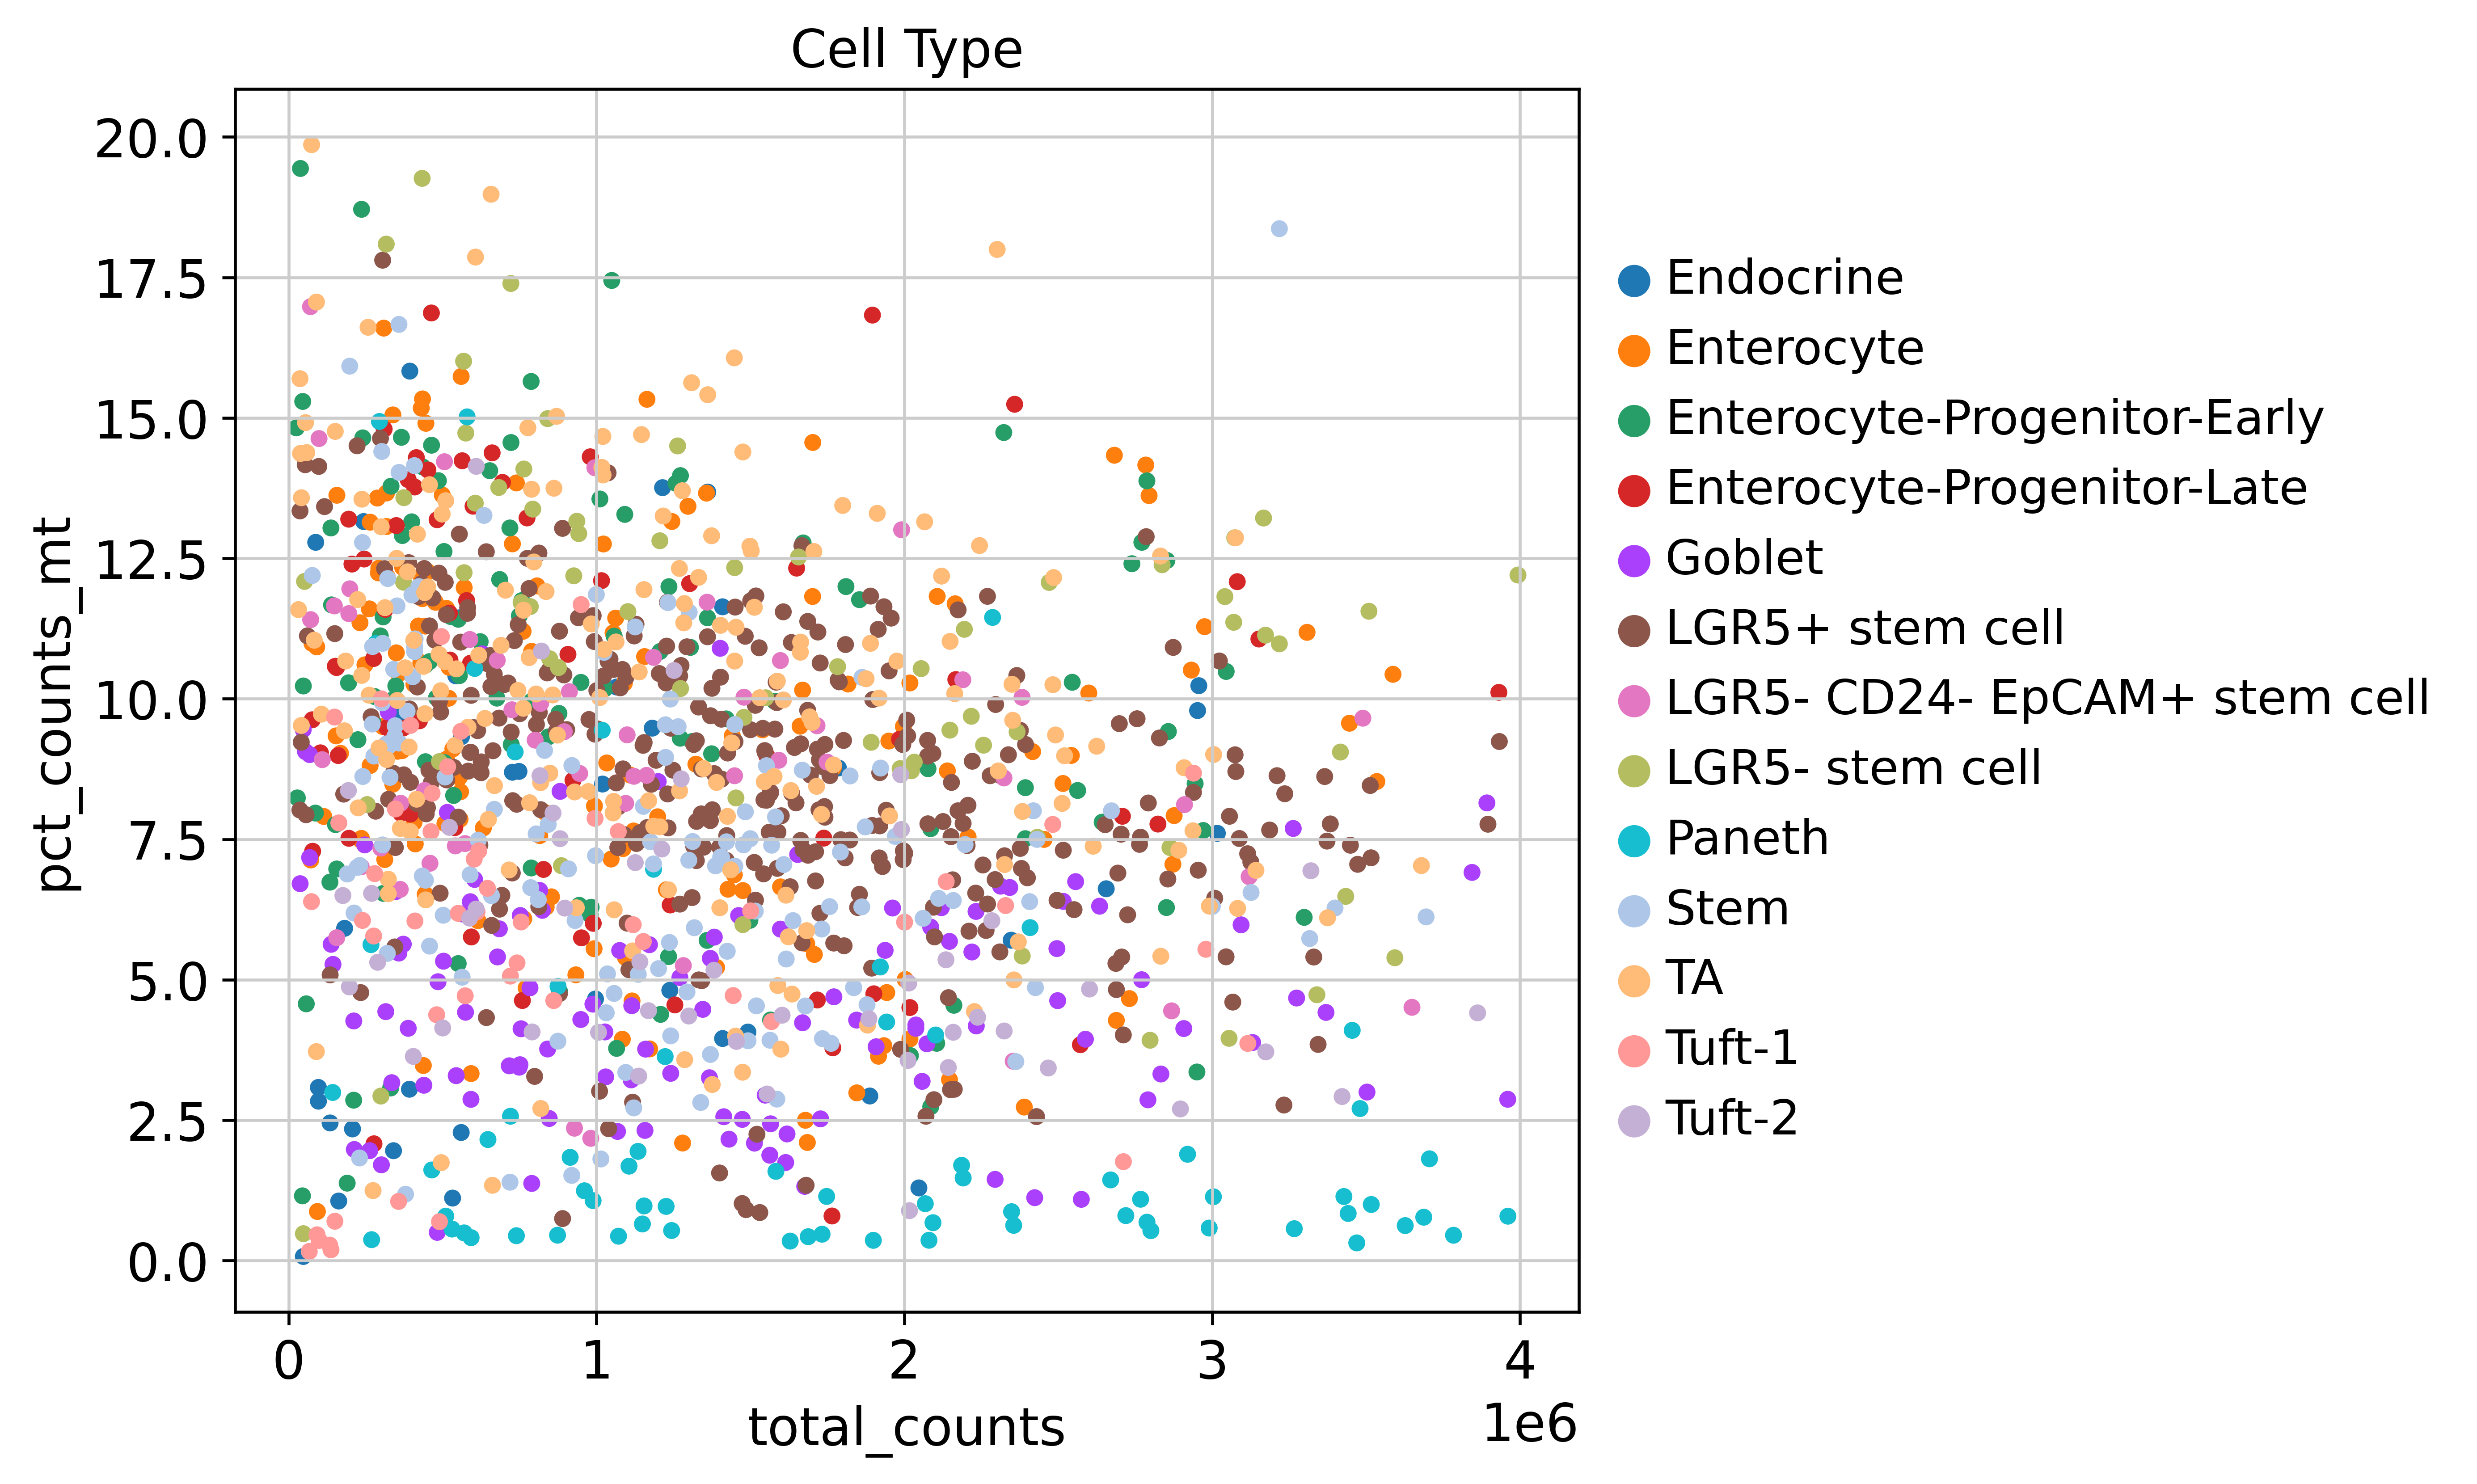

In [159]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_filtered, x = 'total_counts', y = 'pct_counts_mt', color = "Cell_Type")

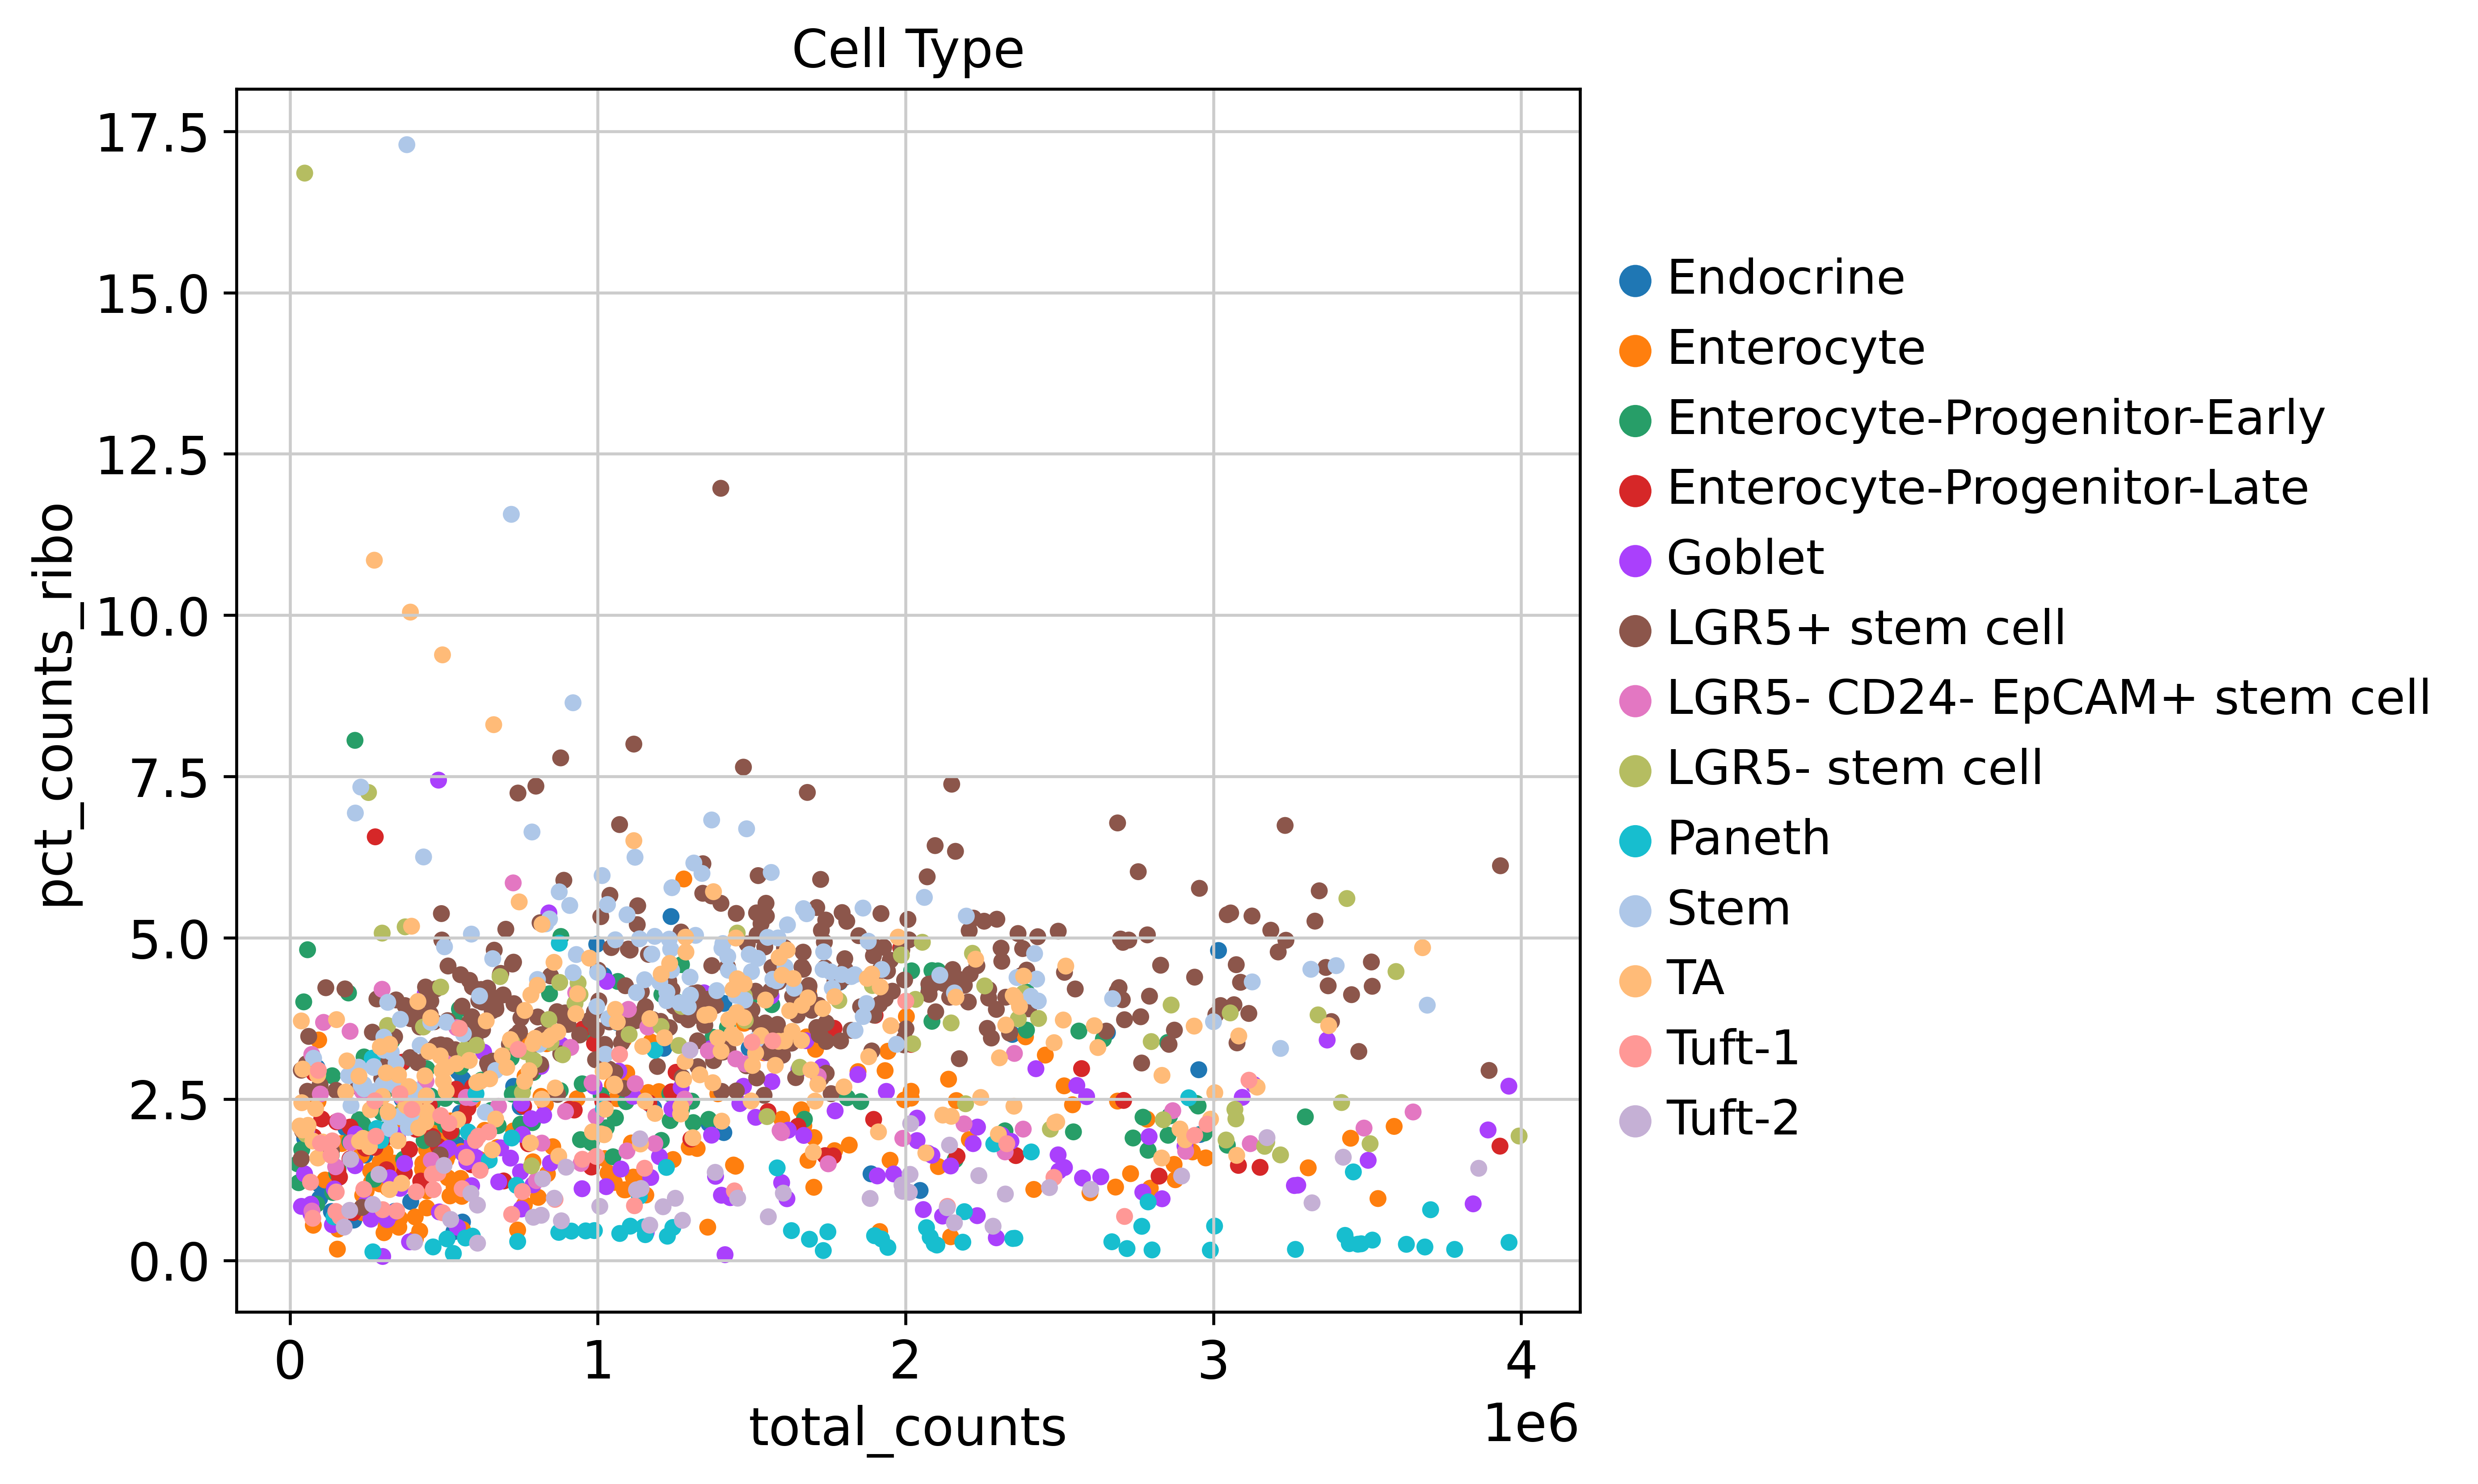

In [160]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_filtered, x = 'total_counts', y = 'pct_counts_ribo', color = "Cell_Type")

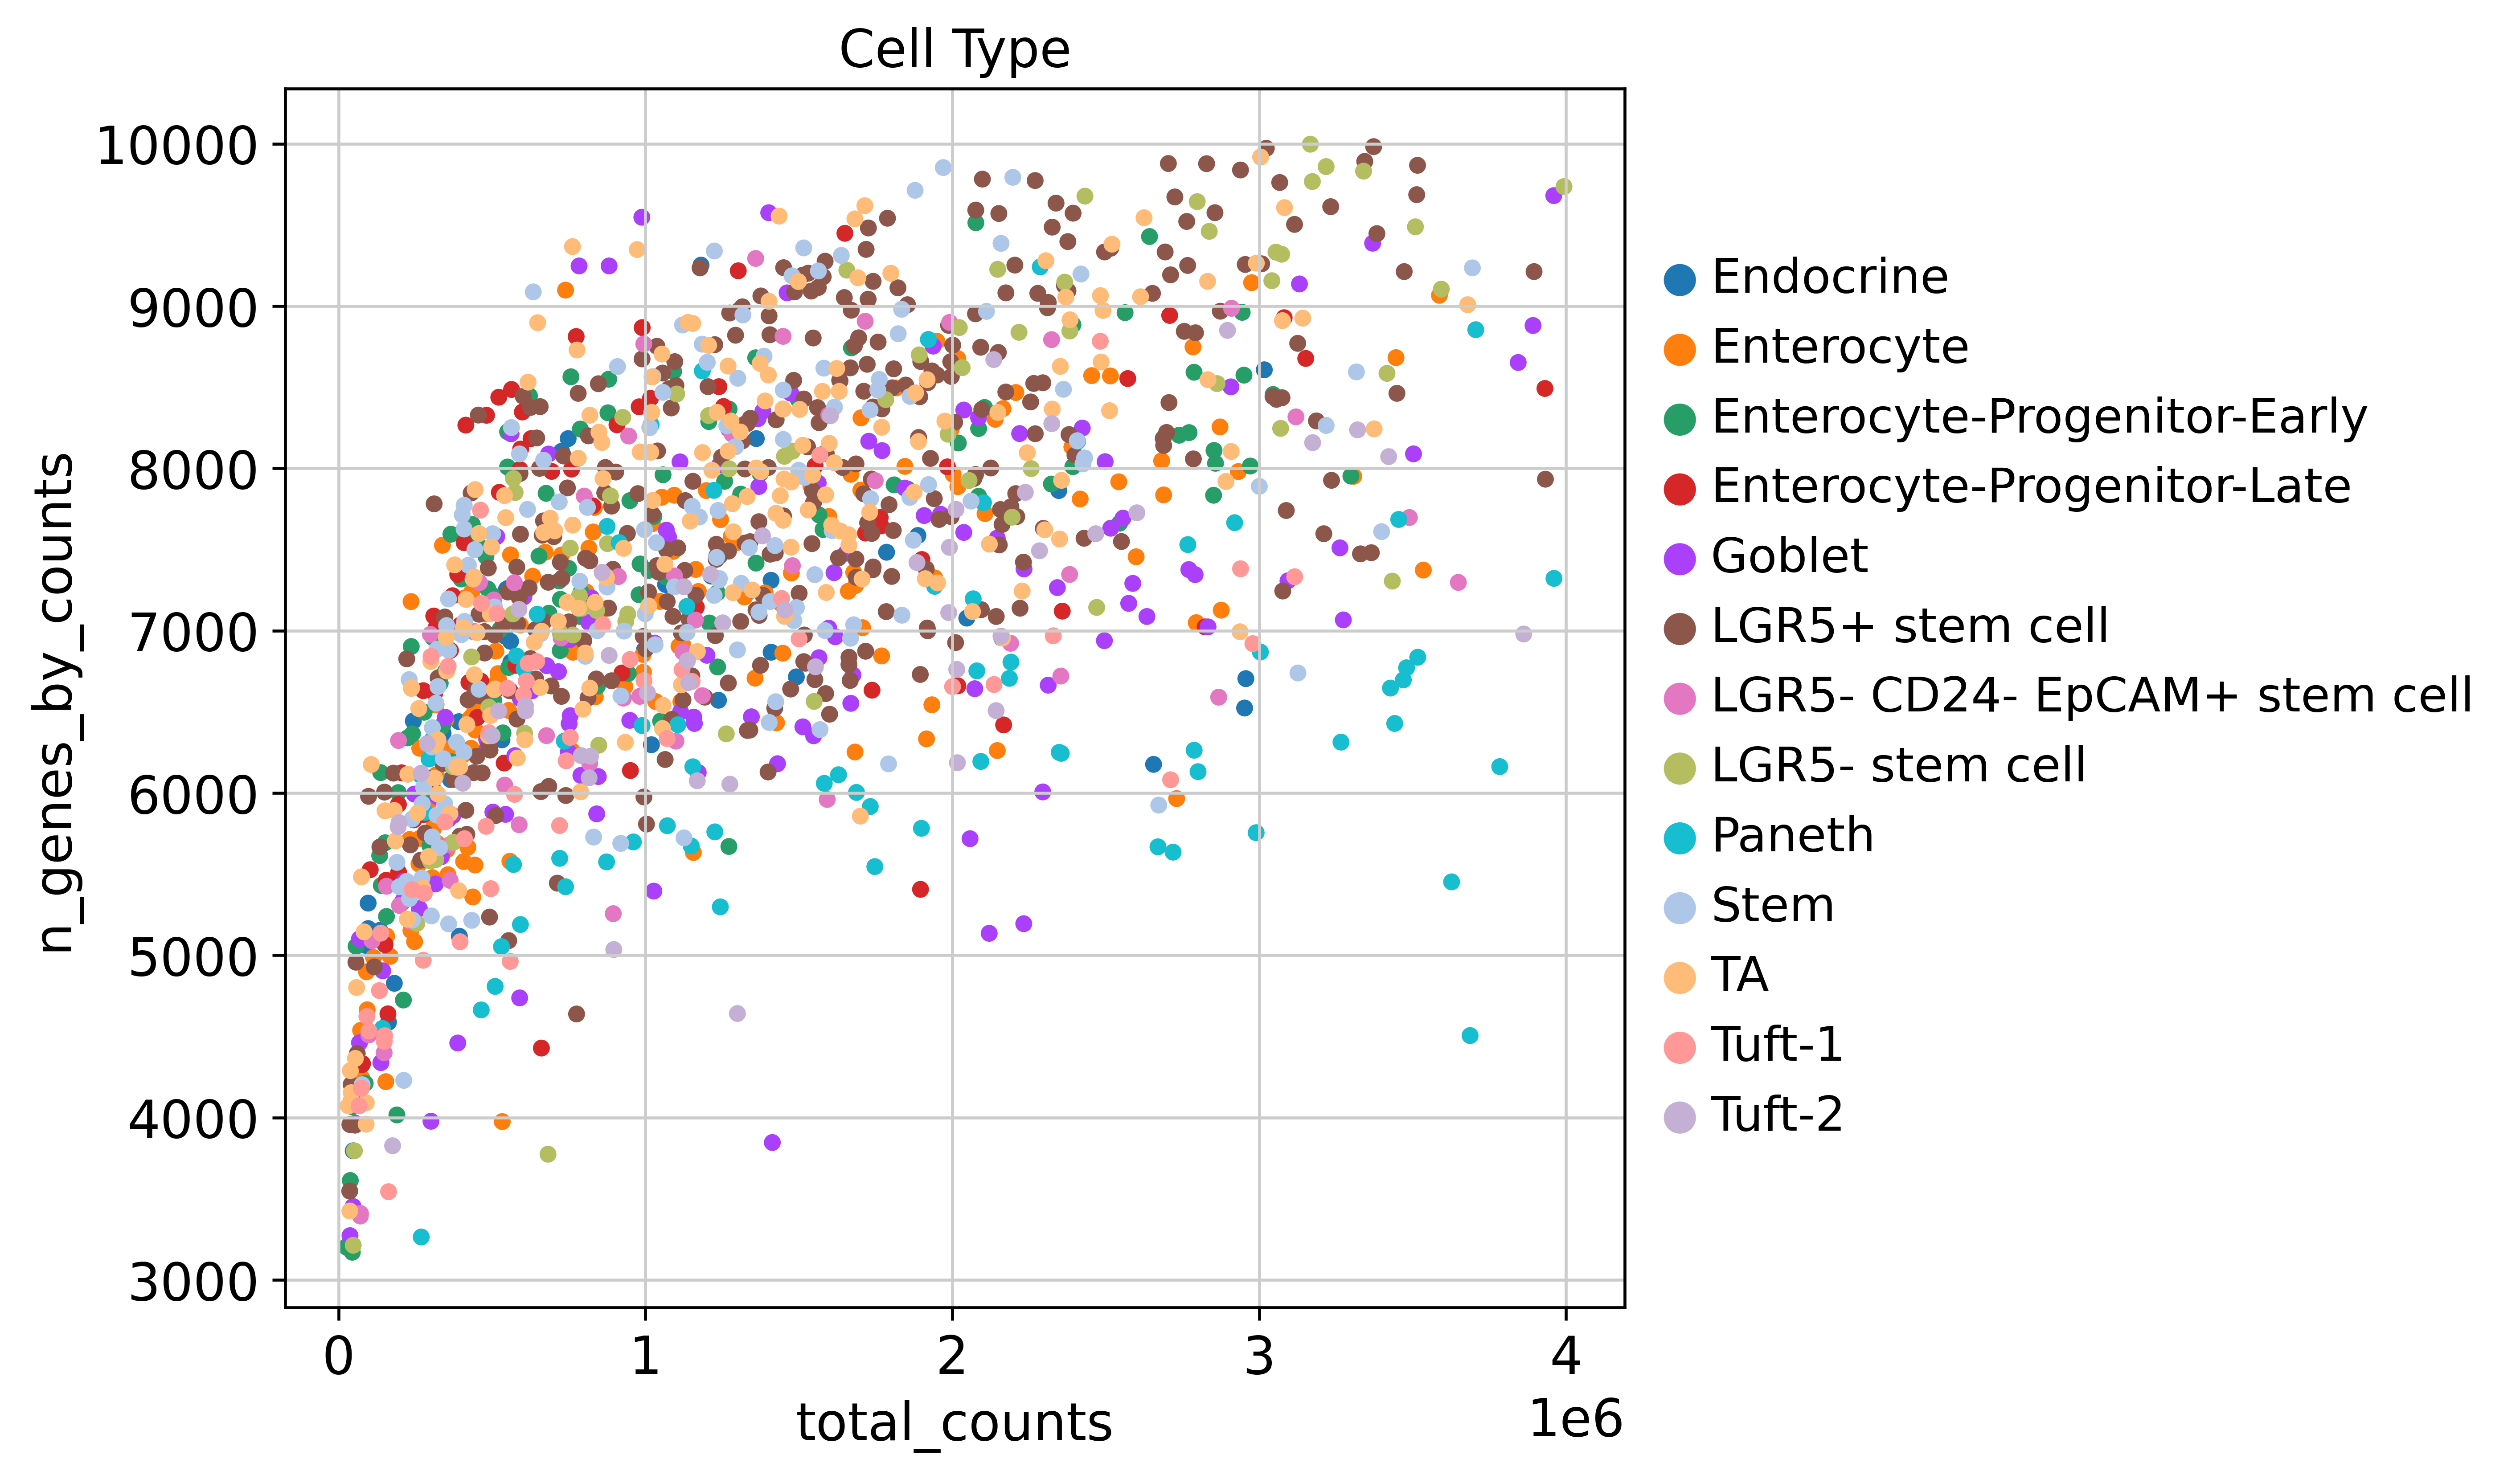

In [161]:
sc.set_figure_params(dpi=300, figsize=(6,6))
sc.pl.scatter(adata_filtered, x = 'total_counts', y = 'n_genes_by_counts', color = "Cell_Type")

In [162]:
adata_filtered

View of AnnData object with n_obs × n_vars = 1453 × 51241
    obs: 'barcode', 'Gene_marker', 'Donor_ID', 'GFP_intensity', 'Cell_Type', 'cell_type_extended', 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'ensemble_gene_id_version', 'ensemble_gene_id', 'start_position', 'end_position', 'chromosome_name', 'external_gene_name', 'n_counts', 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'processing_history', 'Cell_Type_colors'

* Save filtered object

In [164]:
project = 'gut'
species = 'mm'
atribute = 'Haber2017_SmartSeq2_QCfiltered'
name = 'AM'
counts = 'raw'

adata_filtered.uns['processing_history'] = []
adata_filtered.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'QC metrics added, filtering: > 100 n_genes_by_counts < 10000; > 100 total_counts < 4000000; pct_counts_mt < 20, pct_counts_ribo < 20',}

adata_filtered.write_h5ad(f"raw_data/Haber_2017/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

/tmp/ipykernel_548141/1382774267.py:7: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata_filtered.uns['processing_history'] = []
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
